In [116]:
import numpy as np

def directed_hausdorff(A, B):
    max_min_dist = 0.0

    for a in A:
        dists = np.linalg.norm(B - a, axis=1)
        min_dist = np.min(dists)
        max_min_dist = max(max_min_dist, min_dist)

    return max_min_dist


def hausdorff_distance(A, B):
    return max(
        directed_hausdorff(A, B),
        directed_hausdorff(B, A)
    )
import numpy as np

def normalize_contour(contour):
    contour = contour.astype(np.float64)
    # środek ciężkości
    centroid = np.mean(contour, axis=0)
    # przesunięcie do (0,0)
    contour = contour - centroid
    # największa odległość od środka
    radius = np.max(np.linalg.norm(contour, axis=1))
    # skalowanie do koła jednostkowego
    if radius > 0:
        contour = contour / radius
    return contour

In [117]:
import cv2
import matplotlib.pyplot as plt


def contour_bmp(img):
  _, thresh = cv2.threshold(
      img, 127, 255,
      cv2.THRESH_BINARY
  )
  thresh = cv2.bitwise_not(thresh)
  contours, hierarchy = cv2.findContours(
      thresh,
      cv2.RETR_EXTERNAL,
      cv2.CHAIN_APPROX_NONE
  )

  contour = contours[0][:,0,:]
  contour_norm  = normalize_contour(contour)
  return contour_norm

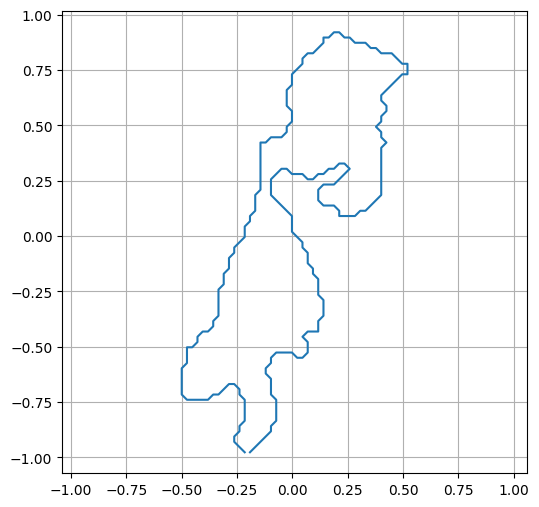

In [120]:
img = cv2.imread("/content/drive/MyDrive/Materials/ithaca_q.bmp", 0)
contour_norm = contour_bmp(img)
plt.figure(figsize=(6,6))
plt.plot(contour_norm[:,0], contour_norm[:,1])
plt.axis('equal')
plt.grid()
plt.show()

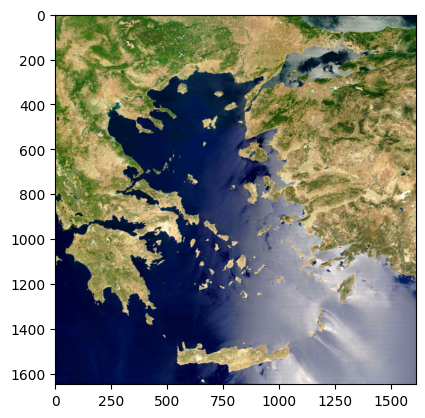

In [96]:
img = cv2.imread("/content/drive/MyDrive/Materials/Aegeansea.jpg")
aeg_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(aeg_rgb)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Perform color-segmentation to get the binary mask
lwr = np.array([100, 100, 5])
upr = np.array([179, 255, 146])
msk = cv2.inRange(hsv, lwr, upr)

# Extracting the rod using binary-mask
krn = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 3))
dlt = cv2.dilate(msk, krn, iterations=5)
res = 255 - cv2.bitwise_and(dlt, msk)





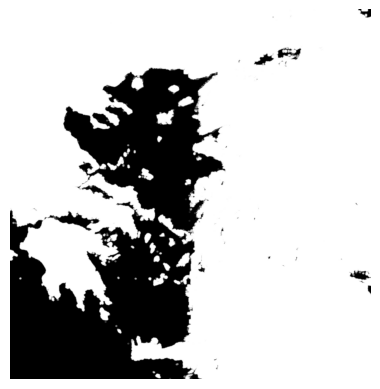

In [103]:
plt.imshow(res, cmap='gray')
plt.axis('off')
plt.show()
# res = cv2.GaussianBlur(res, (5, 5), 0)
# kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
# res = cv2.morphologyEx(res, cv2.MORPH_CLOSE, kernel)
# res = cv2.morphologyEx(res,cv2.MORPH_DILATE,kernel)
# plt.imshow(res, cmap='gray')
# plt.axis('off')
# plt.show()

Found 50 contours.


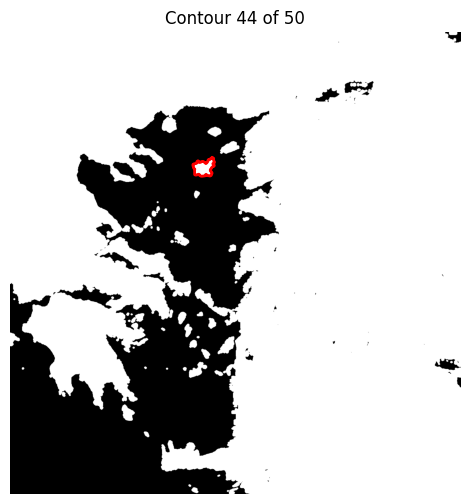

In [113]:

_, thresh = cv2.threshold(
    res, 127, 255,
    cv2.THRESH_BINARY
)
contours, hierarchy = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

print(f"Found {len(contours)} contours.")

ctrs = []
# Iterate through each contour
for i, current_contour in enumerate(contours):
    current_contour = current_contour[:, 0, :]

    if i ==44:
      plt.figure(figsize=(6,6))
      plt.imshow(thresh, cmap='gray') # Show the thresholded image as background
      plt.plot(current_contour[:, 0], current_contour[:, 1], color='red', linewidth=2)
      plt.title(f'Contour {i} of {len(contours)}')
      plt.axis('off')
      plt.show()
    ctrs.append(normalize_contour(current_contour))



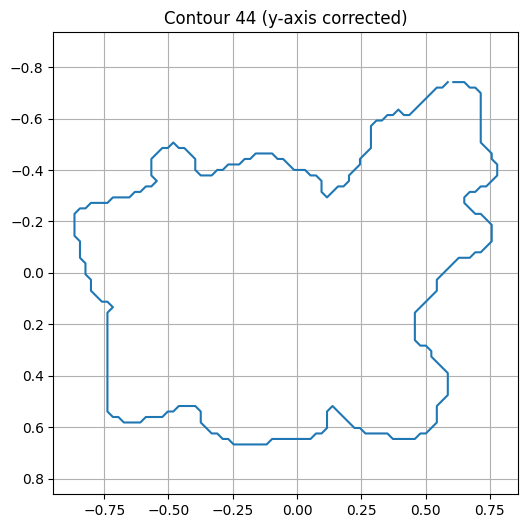

In [112]:
plt.figure(figsize=(6,6))
plt.plot(ctrs[44][:,0], ctrs[44][:,1])
plt.gca().invert_yaxis()          # ← This fixes it
plt.axis('equal')
plt.grid()
plt.title('Contour 44 (y-axis corrected)')
plt.show()

In [121]:
import cv2
from pathlib import Path
from typing import List, Tuple

img_dir = Path("/content/drive/MyDrive/Materials/imgs")
bmp_files = sorted(img_dir.glob("*.bmp"))

def load_images_with_names(directory: Path) -> List[Tuple[np.ndarray, str]]:
    image_list = []

    for file_path in sorted(directory.glob("*.bmp")):
        img = cv2.imread(str(file_path),0)

        if img is None:
            print(f"Could not read: {file_path.name}")
            continue
        contour_norm = contour_bmp(img)
        # Get name without extension (e.g. "c_andros")
        name = file_path.stem

        image_list.append((contour_norm, name))
        print(f"Loaded: {name}  (shape: {img.shape})")

    print(f"\nTotal images loaded: {len(image_list)}")
    return image_list

ctrs_with_names = load_images_with_names(img_dir)




Loaded: c_amorgos  (shape: (120, 186))
Loaded: c_anafi  (shape: (46, 77))
Loaded: c_andros  (shape: (215, 177))
Loaded: c_antiparos  (shape: (78, 46))
Loaded: c_astipalea  (shape: (96, 115))
Loaded: c_folegandros  (shape: (54, 68))
Loaded: c_giaros  (shape: (37, 56))
Loaded: c_ios  (shape: (98, 87))
Loaded: c_kea  (shape: (115, 85))
Loaded: c_kimolos  (shape: (50, 49))
Loaded: c_milos  (shape: (90, 125))
Loaded: c_mykonos  (shape: (72, 91))
Loaded: c_naxos  (shape: (194, 157))
Loaded: c_paros  (shape: (126, 106))
Loaded: c_poliegos  (shape: (34, 37))
Loaded: c_rinia  (shape: (54, 40))
Loaded: c_rithnos  (shape: (129, 85))
Loaded: c_santorini  (shape: (105, 79))
Loaded: c_serifos  (shape: (74, 78))
Loaded: c_sikinos  (shape: (60, 75))
Loaded: c_siros  (shape: (109, 74))
Loaded: c_tinos  (shape: (107, 155))
Loaded: d_aghathonisi  (shape: (29, 52))
Loaded: d_fourni  (shape: (90, 42))
Loaded: d_halki  (shape: (35, 62))
Loaded: d_ikaria  (shape: (68, 92))
Loaded: d_kalimnos  (shape: (105, 9

In [129]:
labels = []
matches = []

for i, c1 in enumerate(ctrs):
    best_dist = np.inf
    best_name = "Unknown"
    best_idx = -1

    for j, (c2, name) in enumerate(ctrs_with_names):
        d = hausdorff_distance(c1, c2)
        if d < best_dist:
            best_dist = d
            best_name = name
            best_idx = j

    labels.append(best_name)
    matches.append((i, best_name, best_dist))
    print(f"Contour {i:2d} → {best_name:15s} (dist: {best_dist:.4f})")

Contour  0 → d_ikaria        (dist: 0.2764)
Contour  1 → c_poliegos      (dist: 0.2446)
Contour  2 → c_poliegos      (dist: 0.2365)
Contour  3 → s_skiathos      (dist: 0.2972)
Contour  4 → c_poliegos      (dist: 0.1881)
Contour  5 → sg_kythira      (dist: 0.2163)
Contour  6 → sa_spetses      (dist: 0.1881)
Contour  7 → d_nissiros      (dist: 0.2508)
Contour  8 → d_nissiros      (dist: 0.2100)
Contour  9 → d_nissiros      (dist: 0.2544)
Contour 10 → c_poliegos      (dist: 0.2476)
Contour 11 → c_sikinos       (dist: 0.2586)
Contour 12 → d_nissiros      (dist: 0.2261)
Contour 13 → d_nissiros      (dist: 0.2314)
Contour 14 → sa_spetses      (dist: 0.2220)
Contour 15 → d_nissiros      (dist: 0.2508)
Contour 16 → sa_megalonisos  (dist: 0.1427)
Contour 17 → c_sikinos       (dist: 0.2400)
Contour 18 → d_nissiros      (dist: 0.2123)
Contour 19 → c_rithnos       (dist: 0.3653)
Contour 20 → c_poliegos      (dist: 0.2294)
Contour 21 → c_rithnos       (dist: 0.2395)
Contour 22 → d_nissiros      (di

=== MATCHING RESULTS ===

Contour  0 → Unknown            (dist: 0.2764)
Contour  1 → c_poliegos         (dist: 0.2446)
Contour  2 → c_poliegos         (dist: 0.2365)
Contour  3 → Unknown            (dist: 0.2972)
Contour  4 → c_poliegos         (dist: 0.1881)
Contour  5 → sg_kythira         (dist: 0.2163)
Contour  6 → sa_spetses         (dist: 0.1881)
Contour  7 → Unknown            (dist: 0.2508)
Contour  8 → d_nissiros         (dist: 0.2100)
Contour  9 → Unknown            (dist: 0.2544)
Contour 10 → c_poliegos         (dist: 0.2476)
Contour 11 → Unknown            (dist: 0.2586)
Contour 12 → d_nissiros         (dist: 0.2261)
Contour 13 → d_nissiros         (dist: 0.2314)
Contour 14 → sa_spetses         (dist: 0.2220)
Contour 15 → Unknown            (dist: 0.2508)
Contour 16 → sa_megalonisos     (dist: 0.1427)
Contour 17 → c_sikinos          (dist: 0.2400)
Contour 18 → d_nissiros         (dist: 0.2123)
Contour 19 → Unknown            (dist: 0.3653)
Contour 20 → c_poliegos         (d

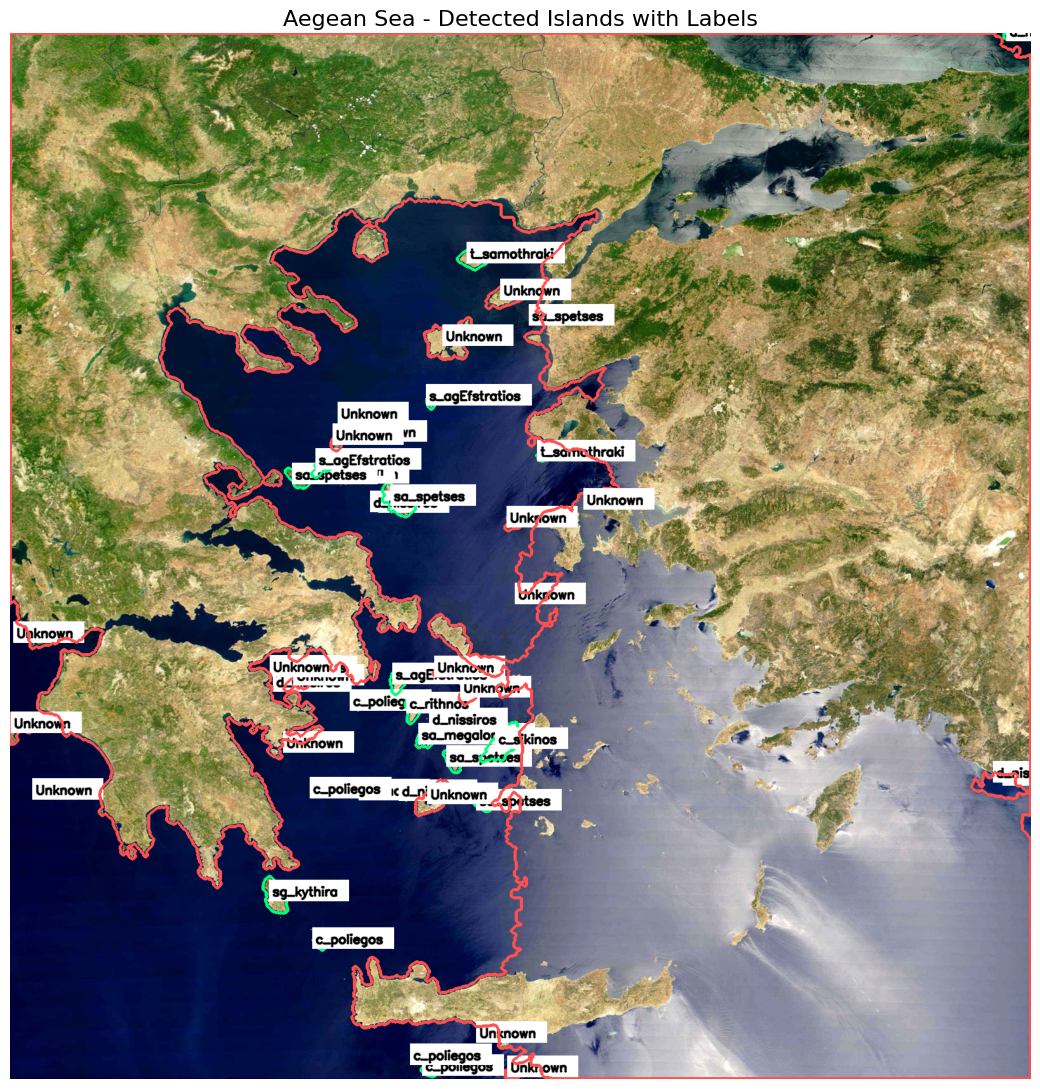


✅ Result saved to: /content/drive/MyDrive/Materials/Aegeansea_labeled_final.jpg


In [130]:
original = cv2.imread("/content/drive/MyDrive/Materials/Aegeansea.jpg")
labeled = cv2.cvtColor(original, cv2.COLOR_BGR2RGB).copy()

for i, (contour, name) in enumerate(zip(contours, labels)):
    if name == "Unknown":
        continue

    # Get centroid
    M = cv2.moments(contour)
    if M["m00"] == 0:
        continue
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    # Draw label
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(labeled, name, (cx-20, cy), font, 0.7, (0, 0, 0), 3, cv2.LINE_AA)
    cv2.putText(labeled, name, (cx-20, cy), font, 0.7, (255, 255, 255), 2, cv2.LINE_AA)

plt.figure(figsize=(14, 10))
plt.imshow(labeled)
plt.title("Aegean Sea - Islands Labeled")
plt.axis('off')
plt.show()

# Save result
cv2.imwrite("/content/drive/MyDrive/Materials/Aegeansea_labeled_final.jpg",
            cv2.cvtColor(labeled, cv2.COLOR_RGB2BGR))